In [1]:

# Heart Disease Prediction Using the Framingham Dataset
# National College of Ireland


# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# Save trained model
import joblib

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [2]:
# ============================================================
# Load the Framingham Dataset
# ============================================================

framingham = pd.read_csv("/content/framingham.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", framingham.shape)

framingham.head()

Dataset loaded successfully.
Dataset shape: (4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


# 1. Dataset Overview

One of the most commonly used cardiovascular datasets for predicting the risk of coronary heart disease (CHD) is the Framingham Heart Study dataset. It includes demographic, behavioral and clinical data from individuals involved in the Framingham Heart Study.

This notebook aims to build and test machine learning models to predict the likelihood of having coronary heart disease after 10 years.

In [3]:
# ============================================================
# Explore the Dataset
# ============================================================

print("First Five Records")
display(framingham.head())

print("\nDataset Information")
framingham.info()

print("\nStatistical Summary")
display(framingham.describe())

print("\nMissing Values")
display(framingham.isnull().sum())

First Five Records


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 5

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000



Missing Values


,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


# 2. Data Preprocessing

The data set needs to be preprocessed prior to the machine learning models being trained. This stage involves identifying missing values, dealing with the incomplete records, segregating the input features from the target variable and the generation of training and test datasets. Again, good data preparation enhances quality of data and enables the models to learn real patterns.

In [4]:
# ============================================================
# Handle Missing Values
# ============================================================

print("Missing values before preprocessing:\n")
print(framingham.isnull().sum())

# Fill missing numerical values using the median
framingham["education"].fillna(framingham["education"].median(), inplace=True)
framingham["cigsPerDay"].fillna(framingham["cigsPerDay"].median(), inplace=True)
framingham["BPMeds"].fillna(framingham["BPMeds"].mode()[0], inplace=True)
framingham["totChol"].fillna(framingham["totChol"].median(), inplace=True)
framingham["BMI"].fillna(framingham["BMI"].median(), inplace=True)
framingham["heartRate"].fillna(framingham["heartRate"].median(), inplace=True)
framingham["glucose"].fillna(framingham["glucose"].median(), inplace=True)

print("\nMissing values after preprocessing:\n")
print(framingham.isnull().sum())

Missing values before preprocessing:

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Missing values after preprocessing:

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


/tmp/ipykernel_822/1360119777.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  framingham["education"].fillna(framingham["education"].median(), inplace=True)
/tmp/ipykernel_822/1360119777.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].metho

## Feature Selection

In this study, the target variable is what we want to know if a patient will develop coronary heart disease in the next 10 years, or "TenYearCHD".

The rest of the variable is considered as predictor features.

In [5]:
# ============================================================
# Separate Features and Target Variable
# ============================================================

X = framingham.drop("TenYearCHD", axis=1)
y = framingham["TenYearCHD"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (4240, 15)
Target vector shape: (4240,)


In [6]:
# ============================================================
# Split Dataset into Training and Testing Sets
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples :", X_train.shape)
print("Testing samples  :", X_test.shape)

Training samples : (3392, 15)
Testing samples  : (848, 15)


# 3. Exploratory Data Analysis (EDA)

Before creating models, it is helpful to understand the structure of the data set by using a technique called Exploratory Data Analysis (EDA). In this section, the distribution of the classes, relationships between the features and the statistics of the variables are discussed.

The visualisations give insight in the balance of the target variable, as well as the distribution of the important cardiovascular risk factors.

/tmp/ipykernel_822/1661189511.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


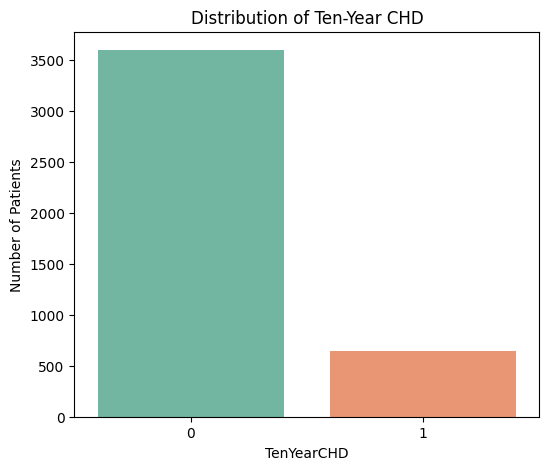

In [7]:
# ============================================================
# Target Variable Distribution
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=framingham,
    x="TenYearCHD",
    palette="Set2"
)

plt.title("Distribution of Ten-Year CHD")
plt.xlabel("TenYearCHD")
plt.ylabel("Number of Patients")

plt.show()

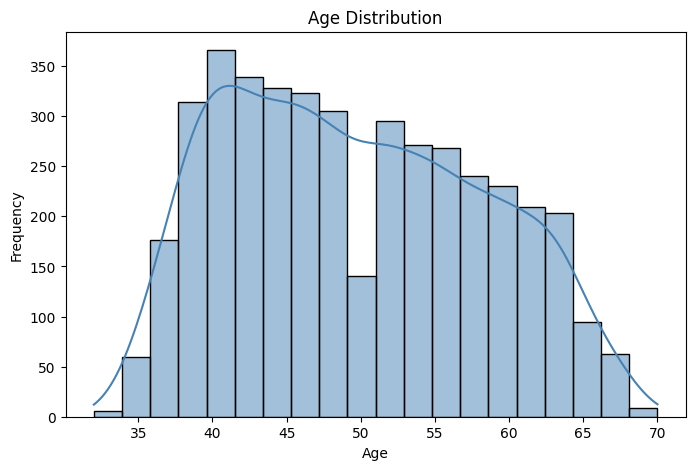

In [8]:
# ============================================================
# Age Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    framingham["age"],
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

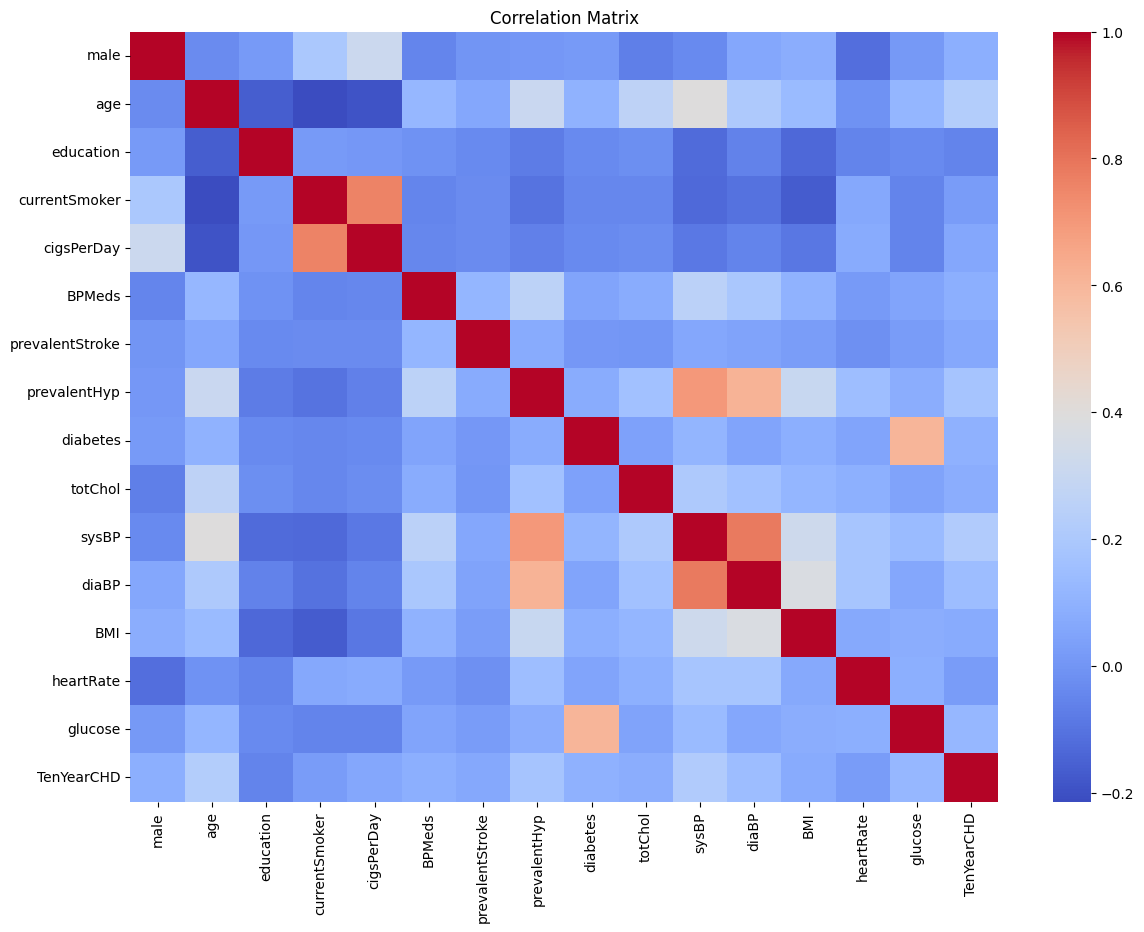

In [9]:
# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(14,10))

sns.heatmap(
    framingham.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

In [10]:
# ============================================================
# Percentage of Target Classes
# ============================================================

class_distribution = (
    framingham["TenYearCHD"]
    .value_counts(normalize=True)
    * 100
)

print("Target Class Distribution (%)")

print(class_distribution)

Target Class Distribution (%)
TenYearCHD
0    84.811321
1    15.188679
Name: proportion, dtype: float64


# 4. Feature Scaling and Class Balancing

Machine learning algorithms often perform better when numerical features are on a similar scale. Standardisation was applied to the predictor variables before model training.

The target variable in the Framingham dataset is imbalanced, with considerably fewer positive CHD cases than negative cases. To reduce the effect of this imbalance, the Synthetic Minority Over-sampling Technique (SMOTE) was applied to the training data.

In [11]:
# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [12]:
# ============================================================
# Handle Class Imbalance Using SMOTE
# ============================================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Original Training Shape:")
print(X_train.shape, y_train.shape)

print("\nBalanced Training Shape:")
print(X_train_smote.shape, y_train_smote.shape)

Original Training Shape:
(3392, 15) (3392,)

Balanced Training Shape:
(5754, 15) (5754,)


# 5. Machine Learning Model Development

Three supervised machine learning models were evaluated for predicting the ten-year risk of coronary heart disease.

The objective was to compare model performance using common classification metrics and select the most appropriate model for deployment.

In [13]:
# ============================================================
# Logistic Regression
# ============================================================

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_test_scaled)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [14]:
# ============================================================
# Random Forest
# ============================================================

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

print("Random Forest training completed.")

Random Forest training completed.


In [15]:
# ============================================================
# Random Forest with SMOTE
# ============================================================

rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

rf_smote_predictions = rf_smote.predict(X_test_scaled)

print("Random Forest with SMOTE training completed.")

Random Forest with SMOTE training completed.


# 6. Model Evaluation

The trained models were evaluated using standard binary classification metrics.

The following metrics were considered:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics provide a balanced assessment of model performance, particularly for datasets with class imbalance.

In [16]:
# ============================================================
# Logistic Regression Evaluation
# ============================================================

print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

print("Accuracy :", accuracy_score(y_test, logistic_predictions))
print("Precision:", precision_score(y_test, logistic_predictions))
print("Recall   :", recall_score(y_test, logistic_predictions))
print("F1 Score :", f1_score(y_test, logistic_predictions))

print("\nClassification Report\n")
print(classification_report(y_test, logistic_predictions))

LOGISTIC REGRESSION
Accuracy : 0.8443396226415094
Precision: 0.4117647058823529
Recall   : 0.05426356589147287
F1 Score : 0.0958904109589041

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.99      0.91       719
           1       0.41      0.05      0.10       129

    accuracy                           0.84       848
   macro avg       0.63      0.52      0.51       848
weighted avg       0.79      0.84      0.79       848



In [17]:
# ============================================================
# Random Forest Evaluation
# ============================================================

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)

print("Accuracy :", accuracy_score(y_test, rf_predictions))
print("Precision:", precision_score(y_test, rf_predictions))
print("Recall   :", recall_score(y_test, rf_predictions))
print("F1 Score :", f1_score(y_test, rf_predictions))

print("\nClassification Report\n")
print(classification_report(y_test, rf_predictions))

RANDOM FOREST
Accuracy : 0.8490566037735849
Precision: 0.5454545454545454
Recall   : 0.046511627906976744
F1 Score : 0.08571428571428572

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       719
           1       0.55      0.05      0.09       129

    accuracy                           0.85       848
   macro avg       0.70      0.52      0.50       848
weighted avg       0.81      0.85      0.79       848



In [18]:
# ============================================================
# Random Forest + SMOTE Evaluation
# ============================================================

print("=" * 60)
print("RANDOM FOREST WITH SMOTE")
print("=" * 60)

print("Accuracy :", accuracy_score(y_test, rf_smote_predictions))
print("Precision:", precision_score(y_test, rf_smote_predictions))
print("Recall   :", recall_score(y_test, rf_smote_predictions))
print("F1 Score :", f1_score(y_test, rf_smote_predictions))

print("\nClassification Report\n")
print(classification_report(y_test, rf_smote_predictions))

RANDOM FOREST WITH SMOTE
Accuracy : 0.7936320754716981
Precision: 0.2553191489361702
Recall   : 0.18604651162790697
F1 Score : 0.21524663677130046

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       719
           1       0.26      0.19      0.22       129

    accuracy                           0.79       848
   macro avg       0.56      0.54      0.55       848
weighted avg       0.77      0.79      0.78       848



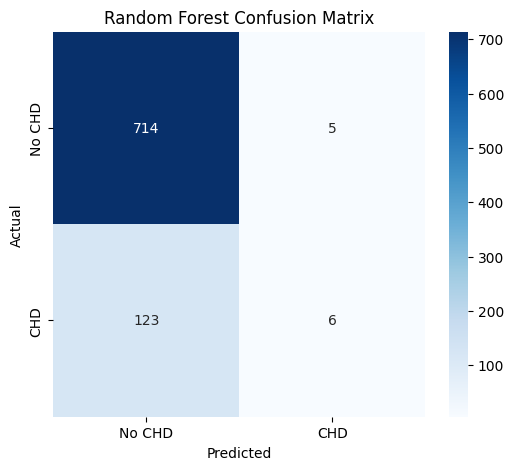

In [19]:
# ============================================================
# Confusion Matrix (Random Forest)
# ============================================================

cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No CHD", "CHD"],
    yticklabels=["No CHD", "CHD"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
# ============================================================
# Model Comparison
# ============================================================

comparison = pd.DataFrame({

    "Model": [

        "Logistic Regression",
        "Random Forest",
        "Random Forest + SMOTE"

    ],

    "Accuracy": [

        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, rf_smote_predictions)

    ],

    "Precision": [

        precision_score(y_test, logistic_predictions),
        precision_score(y_test, rf_predictions),
        precision_score(y_test, rf_smote_predictions)

    ],

    "Recall": [

        recall_score(y_test, logistic_predictions),
        recall_score(y_test, rf_predictions),
        recall_score(y_test, rf_smote_predictions)

    ],

    "F1 Score": [

        f1_score(y_test, logistic_predictions),
        f1_score(y_test, rf_predictions),
        f1_score(y_test, rf_smote_predictions)

    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.844340,0.411765,0.054264,0.095890
1,Random Forest,0.849057,0.545455,0.046512,0.085714
2,Random Forest + SMOTE,0.793632,0.255319,0.186047,0.215247


# 7. Saving the Final Model

After evaluating the candidate machine learning algorithms, the selected deployment model was saved for integration with the Flask web application. Saving the trained model avoids retraining each time the application is started and allows consistent predictions during deployment.

In [21]:
# ============================================================
# Save the Final Deployment Model
# ============================================================

joblib.dump(random_forest, "framingham_model.pkl")

print("✅ Framingham deployment model saved successfully.")

✅ Framingham deployment model saved successfully.


# 8. Conclusion

This notebook presented the complete machine learning workflow for predicting ten-year coronary heart disease risk using the Framingham Heart Study dataset.

The workflow included data exploration, preprocessing, feature preparation, model training, model evaluation and final model selection. Multiple supervised learning algorithms were compared, and the selected Random Forest model was saved for integration into the Flask-based web application developed as part of this project.

The completed model forms one of three prediction modules within the overall Heart Disease Prediction System.